In [2]:
%matplotlib widget
from ipywidgets import *
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import sympy as sym
from sympy import symbols, Matrix, latex, expand, I, simplify
from IPython.display import display, Math
from ipywidgets import interact, FloatSlider


plt.style.use('dark_background')

fontsize = 14
mpl.rcParams.update({
        "text.usetex": False,
        "figure.figsize": (9, 6),
        "figure.autolayout": True,
        "font.family": "serif",
        "font.serif": "georgia",
        # 'mathtext.fontset': 'cm',
        "lines.linewidth": 1.5,
        "font.size": fontsize,
        "xtick.labelsize": fontsize,
        "ytick.labelsize": fontsize,
        "legend.fancybox": True,
        "legend.fontsize": fontsize,
        "legend.framealpha": 0.7,
        "legend.handletextpad": 0.5,
        "legend.labelspacing": 0.2,
        "legend.loc": "best",
        "axes.edgecolor": "#b0b0b0",
        "grid.color": "#707070",  # grid color"
        "xtick.color": "#b0b0b0",
        "ytick.color": "#b0b0b0",
        "savefig.dpi": 80,
        "pdf.compression": 9,
})


# PHY 400 Final Project: Laser Cutters
## By, Carter Thompson

# 1. Introduction

## 1.1. What is a laser cutter?
A laser cutter is a tool often used in manufacturing to cut, engrave, or shape materials with a high precision. Laser cutting process involves heating, melting and evaporation of a material in a small well. Laser cutting is a subtractive manufacturing process where it removes pieces of the material mentioned through the processes above. 

Laser cutting systems are often powered by Computer Numerical Control (CNC) systems. These CNC systems allow for the users to upload G-code of the piece they are manufacturing. This system controls the location of the laser cutting head and helps create the shapes defined in the code.
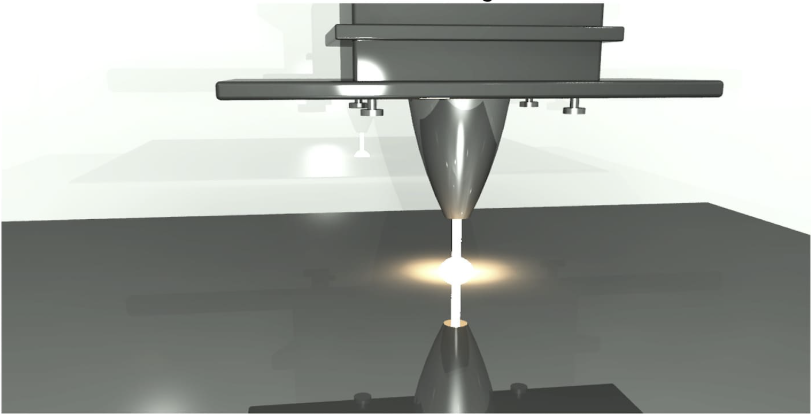

## 1.2. What are the advantages of laser cutters?
1. High Precision
    * Laser cutters have incredibly tight tolerances that can't be achieved by other manufacturing processes (+/- 0.0005")
2. High Speeds
    * The cutting speed varies by material thickness and type but generally the process is faster than conventional machining processes
3. Automation
    * Due to the process being powered by a CNC system the machining process often involves little operator involvment
4. Clean
   * The laser cutting process is relatively clean and doesn't require cutting fluids an/or other chemicals
5. No tooling
   * No additional tooling or processes are required
   * This means no tool wear
   * Reduces the risk of damaging delicate materials
6. Limited Post-Processing
   * Once the piece is processed little needs to be done to clean the parts
7. Material Versatility
   * Can be used to cut a variety of different materials without additional purchases
8. Versatility
   * Can be used for multiple different processes as it can be used to cut or engrave pieces


## 1.3. What are the disadvantages of laser cutters?
1. Limited Material Thickness
   * Laser cutters have a max material thickness they can cut (~25mm)
2. Toxic Fumes
   * When cutting certain materials, the cutting process can generate toxic fumes that requires additional ventilation
3. Power Consumption
   * The laser cutting process consumes a large amount of power
4. Cost/Maintenance
   * Laser cutters are generally more expensive than traditional machining methods
   * Certain laser cutters often require frequent maintenance and replacement parts

# 2. How do laser cutters work?
Laser cutters have three main systems, the laser, optical systems, and the focusing system. These three systems work in tandem to cut different materials. The laser produces the beam which then travels to the optical system. The optical system is a system of reflectors that help direct the beam from the laser to the focusing system. The focusing system then focuses the beam to produce a beam that is capable of cutting the desired material.

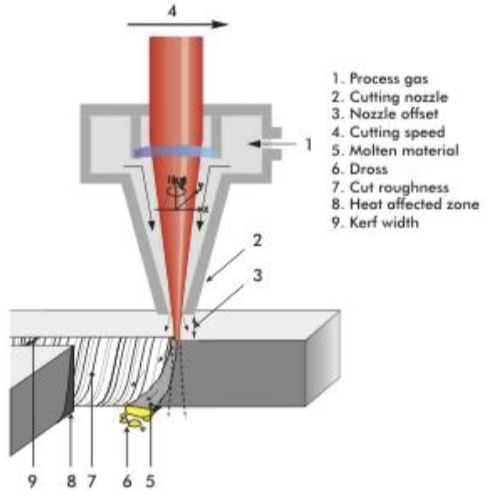

## 2.1. Lasers
The three main types of laser used in laser cutting are as follows:
1. $CO_{2}$ Lasers
2. Nd-YAG (Neodymium Yttrium-Aluminum-Garnet) Lasers
3. Fiber Optic Lasers
Each of these three laser types use different lasing media and operational techniques which allows for a wide range of materials and thicknesses to be cut.

#### 2.1.1 $CO_2$ Laser
The $CO_2$ laser cutting system is the most basic and common laser cutting system available. A $CO_2$ laser is a type of gas laser where electricity is run through a gas-filled tube to produce light.

The ends of the tube there are mirrors one which if fully reflective and the other which lets some of the light through. This cavity is the fabry-perot cavity that we discussed in class.

The gas media of the $CO_2$ laser is generally comprised of $CO_2$, $N_2$, $H_2$, and $He$. The $CO_2$ laser goes through a pumping process which excites the nitrogen molecules in the tube. Once these nitrogen molecules are excited they can excite the $CO_2$ molecules.

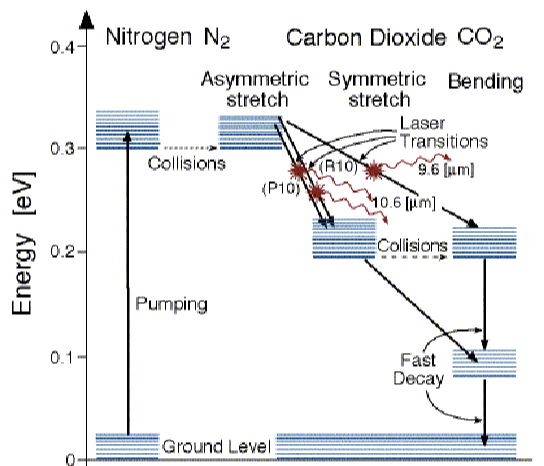

Once the $CO_2$ molecules reach this excited state the laser achieves population inversion. This happens as the excited nitrogen will hit the helium molecules which when this happens causes the $CO_2$ to lose their excited state and emit infrared light at wavelengths of $10.6 \mu m$ or $9.6 \mu m$.

Due to $CO_2$ lasers having an efficiency of ~30% they are often used in laser cutters where they will process organic materials and thick non-metals.

## 2.2. Optical systems
Due to the fact that laser cutters are CNC machines where the cutting head moves constantly, a set of reflecting mirrors are used to help direct the laser to the focusing system located in the cutting head.

These mirrors are known as steering mirrors. They direct the laser and allow for the movement of the cutting head, all while letting the cutting head remain relatively small in size. 

There are a couple different types of mirrors that can be used within laser cutting systems. They are as follows:
1. Si Mirror
   * Silicon glass coated mirrors offer a great reflective index but are not good for applications over 80 watts
2. Mo Mirror
   * Molybdenum mirrors are very tough but have a low reflective index which allows for the use in applications over 80 watts
3. Cu Mirror
   * Copper mirrors are the in between of Si and Mo mirrors in terms of strength and reflective index
  
Each of these mirrors will need to be replaced over the lifespan of the laser cutter which adds to the recurring cost of laser cutters. 

These mirrors will move as the cutting head moves to help direct be beam into the focusing lens. The downside of using this system in a laser cutting system is that as you increase the number of mirrors you will see some loss in power. This loss in power can be calculated as follows:
$$ P = P_o R^{n}$$
Where $P_o$ is the initial power of the laser, R is the reflectivity of the mirrors and n is the number of mirrors.


interactive(children=(FloatSlider(value=0.99, description='R:', max=1.0, step=0.01), Output()), _dom_classes=(…

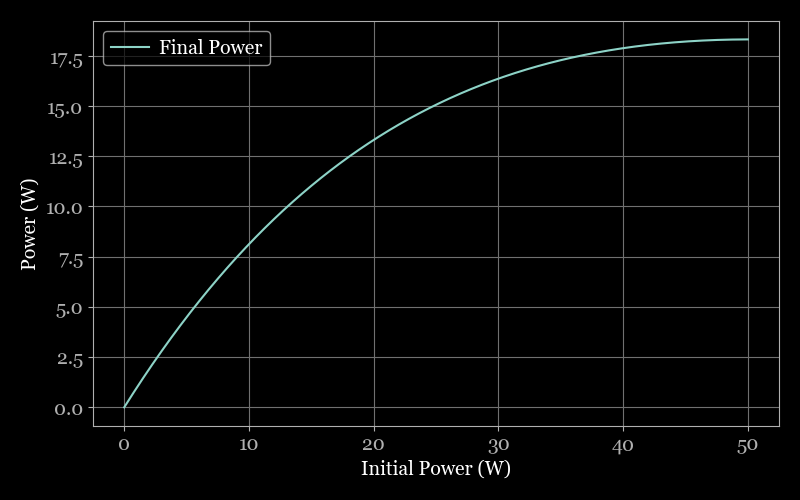

In [7]:
def p(Po, R, n):
    return Po * R**n

Ro = 0.99
n = np.linspace(1, 100, 1000)
Po = np.linspace(0, 50, 1000)

fig, ax = plt.subplots(figsize=(8, 5))
line, = ax.plot(Po, p(Po, Ro, n), label="Final Power")

ax.set_xlabel("Initial Power (W)")
ax.set_ylabel("Power (W)")
ax.grid(True)
ax.legend()

def update_p(r_slider=Ro):
    P = p(Po, r_slider,n)
    line.set_ydata(P)
    fig.canvas.draw_idle()

interact(
    update_p,
    r_slider=FloatSlider(
        value=Ro, min=0, max=1, step=0.01,
        description="R:", continuous_update=True
    ),
)

plt.show()

interactive(children=(FloatSlider(value=3.0, description='n:', max=10.0, step=1.0), Output()), _dom_classes=('…

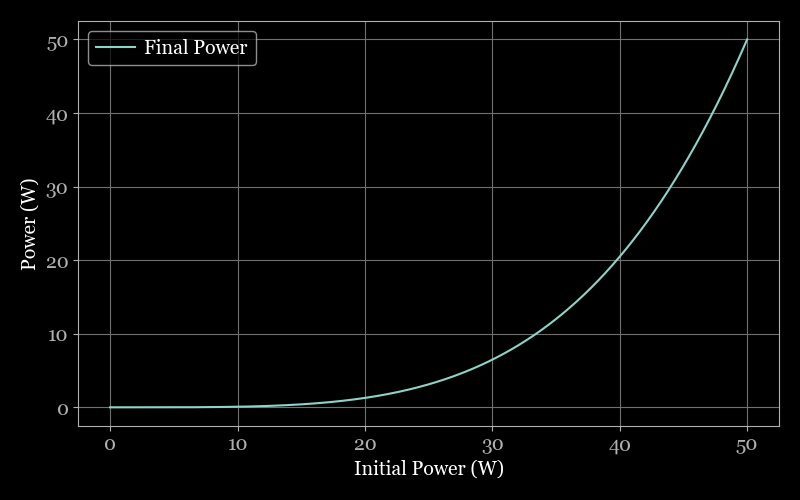

In [8]:
def p(Po, R, n):
    return Po * R**n

no = 3
R = np.linspace(0, 1, 1000)
Po = np.linspace(0, 50, 1000)

fig, ax = plt.subplots(figsize=(8, 5))
line, = ax.plot(Po, p(Po, R, no), label="Final Power")

ax.set_xlabel("Initial Power (W)")
ax.set_ylabel("Power (W)")
ax.grid(True)
ax.legend()

def update_p(n_slider=no):
    P = p(Po, R, n_slider)
    line.set_ydata(P)
    fig.canvas.draw_idle()

interact(
    update_p,
    n_slider=FloatSlider(
        value=no, min=0, max=10, step=1,
        description="n:", continuous_update=True
    ),
)

plt.show()

## 2.3. Focusing system
The goal of the focusing system is to take the laser after its gone through the optical system and focus the beam to a smaller size to increase the intensity of the beam. This is critical as it allows for the $CO_2$ laser to cut through different materials.

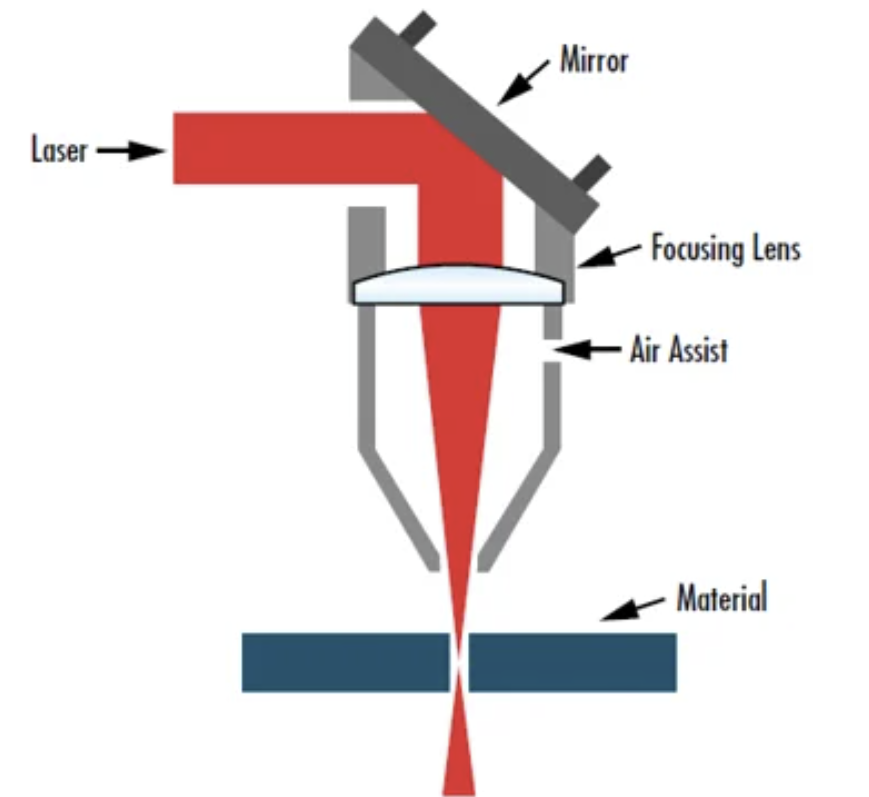

The intensity of the beam after the lens can be calculated through the following:

$$I = I_o e^{-\dfrac{2r^2}{\omega(z)^2}}$$

where
$ \omega(z) = \omega_o \sqrt{1+(\dfrac{\lambda z}{\pi \omega_o^2})^2}$ and $ I_o = \dfrac{2P}{\pi \omega(z)^2} $

$\omega_o$ is the beam waist, r is the radial distance from the axis, and z is the distance from $\omega_o$



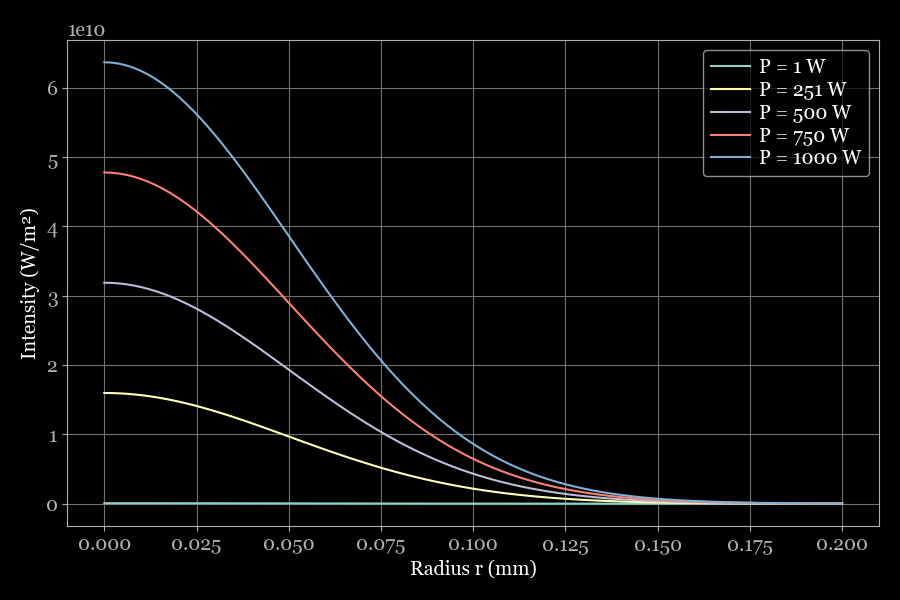

In [5]:
P = np.linspace(1,1000,5)
wo = 0.1*10**-3
l = 10.6*10**-6
z = 0
r = np.linspace(0, 0.2*10**-3,100)

Wz = wo*np.sqrt(1+((l*z)/(np.pi*wo**2))**2)

plt.figure()

for Pi in P:
    I = ((2*Pi)/(np.pi*Wz**2))*np.exp((-2*r**2)/(Wz**2))
    plt.plot(r*1e3, I, label=f"P = {Pi:.0f} W")

plt.xlabel("Radius r (mm)")
plt.ylabel("Intensity (W/m²)")
plt.legend()
plt.grid()
plt.show()

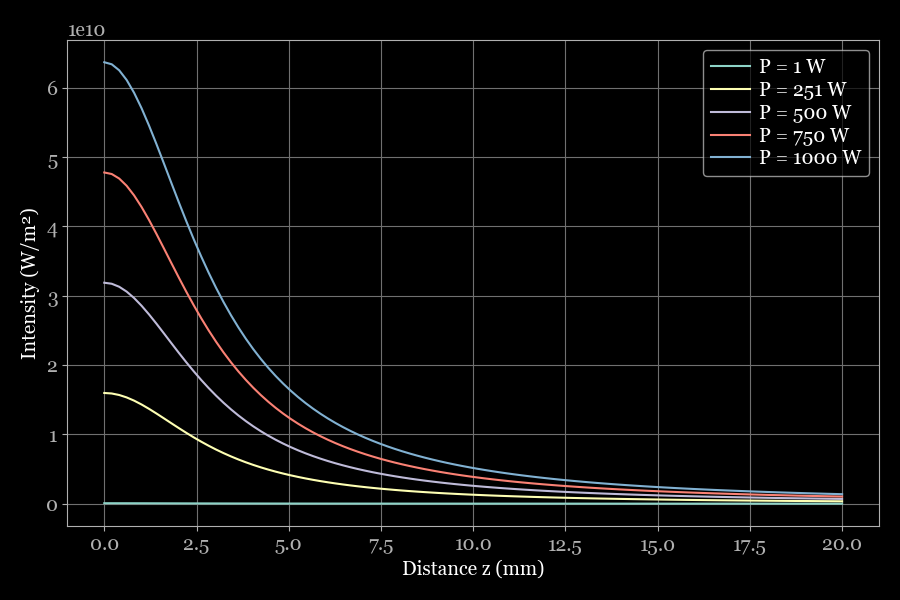

In [6]:
P = np.linspace(1,1000,5)
wo = 0.1*10**-3
l = 10.6*10**-6
z = np.linspace(0,20*10**-3,100)
r = 0

Wz = wo*np.sqrt(1+((l*z)/(np.pi*wo**2))**2)

plt.figure()

for Pi in P:
    I = ((2*Pi)/(np.pi*Wz**2))*np.exp((-2*r**2)/(Wz**2))
    plt.plot(z*1e3, I, label=f"P = {Pi:.0f} W")

plt.xlabel("Distance z (mm)")
plt.ylabel("Intensity (W/m²)")
plt.legend()
plt.grid()
plt.show()

These two plots show how the intensity of the beam will vary as you move away from the central axis of the beam r and away fron the beam spot z. This highlights the critical importance of the CNC aspect of laser cutters. If the CNC is off in either direction the intensity wouldn't be at its peak value which can cause efficiency problems within the laser cutter.

## 2.4. Assist Gases
After the laser has been focused by the focusing system assist gasses are often used. These gasses are often compressed air, nitrogen, oxygen, or argon. These gasses are typically injected into the nozzle of the laser cutter to enhance the cutting process. 

These gasses can facilitate an exothermic reaction, releasing additional thermal energy in the laser that accelerates the material seperation. They also improve heat transfer, blow away molten material, prevent re-solidification on the cut edge, and maintain cut quality. 

For example, oxygen generates extra heat which allows for faster piercing of thick metals, and nitrogen can be used for producing oxide free edges on reactive metals. 

# 3. Different methods of laser cutting
There are four main methods of laser cutting all of which use a different technique to cut the desired materials. These techniques are used in many different industries such as metal fabrication, electronics, automotive, aerospace, and medical device manufacturing. 

## 3.1. Sublimating or Vaporizing
The first method of laser cutting is called sublimating. Sublimation is a process in which the phase of the cut material changes while being cut. The material will transition directly from a solid to a gaseous state without passing through the liquid phase. This process is often done by a high-energy laser beam ($CO_2$ or fiber). 

In this process the laser will rapidly heat the workpiece. This causes immediate vaporization of the target material with minimal melting. This method is important when working with materials that will experience high stresses along the cut area as this method achieves a minimal heat affected zone (see section 4.2.).

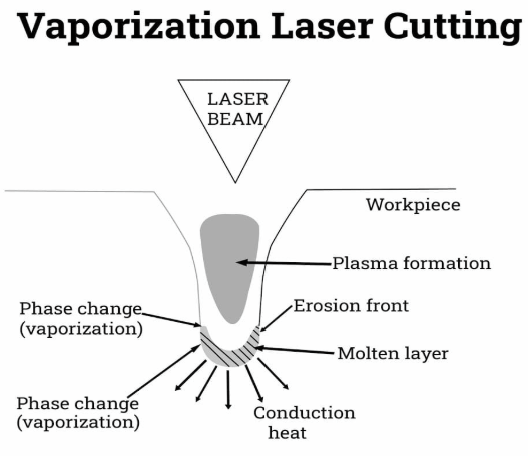

In this manufacturing method the laser will start by making a single pass to form an initial keyhole in the material. Then the localized focus of the laser will increase which enables faster vaporization. This will in turn create a high-pressure jet of vapor that deepens the cut and ejects debris. This process also allows for a narrow kerf width (see section 4.1.). 

This method often gets used for applications where tight tolerances are needed and where the cut material has a low vaporization energy. These materials include:
* Plastics
* Textiles
* Wood
* Paper
* Foam
* Thin Films


## 3.2. Melting (Fusion Cutting)
The process of fusion cutting or melting involves heating the material until it melts. After the material melts a high-pressure jet of gas blows the molten material from the cut. This process requires about 1/10 the energy needed for the previous method vaporization. This process allows for the cut material to remain free of chemical reactions which produces oxide-free and clean cuts with tight tolerances. 

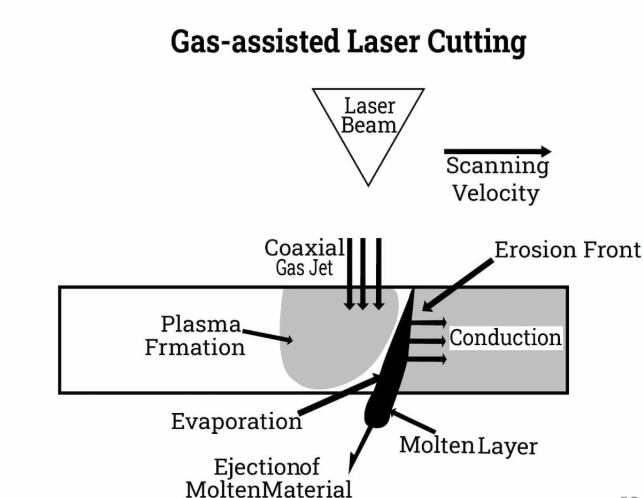

Fusion cutting is best suited for non-oxidizing or active metals including:
* Stainless Steel
* Titanium
* Aluminum alloys

This process is often used in aerospace application where these materials are required. This process maximizes cutting speed while reducing the required heat input all while preventing dislocation or warping. This method is the most common method found in laser cutting as it allows for a high-volume production efficiency.

## 3.3. Reactive Laser Cutting (Flame Cutting/Oxygen-Assisted)
This method uses a reactive gas to amplify the cutting process. This cutting process is performed as the laser will start melting the material all while the gas is directed into the cut zone. This gas then reacts with the heated material which begins an exothermic reaction.

The benefit of this is that this exothermic reaction does most of the heavy lifting for the cut. The input energy required for the laser with this process is much lower as the exothermic reaction produces about 60% of the energy needed for the cut.

Although this process is faster and more energy efficient this process often leaves behind a layer of metal oxide slag along the cut edges. This means that after the cut process some post-processing is required to remove this excess material along the cut.

This process is often used when thicker metals such as carbon steels, titanium steels and easily oxidized metals need to be cut. This process if often used when developing structural components due to the speed at which it can cut thicker metal plates such as gussets.

## 3.4. Thermal Stress Fracture
This method often referred to as laser scribing creates a cut through the controlled fracture of the cut material. This is done as the laser is used to initiate a keyhole (1/3 material thickness). This keyhole creates intense localized heating where when the material is cooled causes the material to fracture cleanly along the path of the laser. 

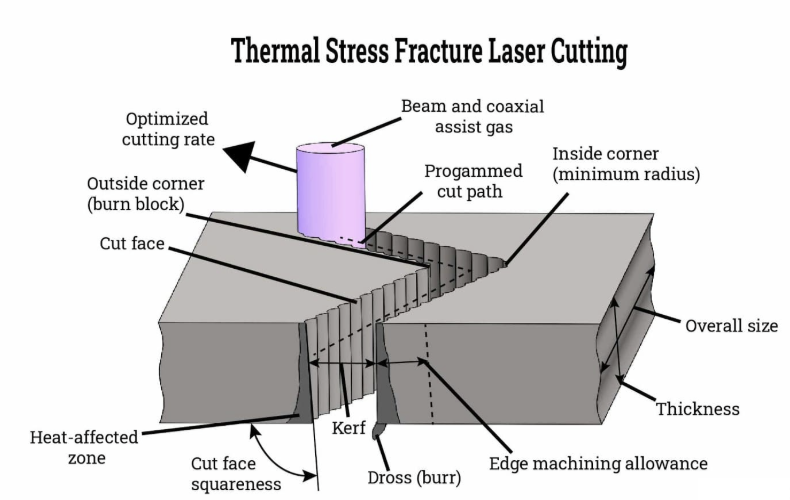

This method if often used when cutting brittle and hard materials such as:
* Glass
* Ceramics
* Composites

$CO_2$ lasers are often used in this cutting method. Due to this process requiring the laser to operate at specific wavelengths to ensure the material fractures in the correct way special machinery is needed for different applications. Often used in semiconductor manufacturing.

# 4. Important concepts in laser cutting

## 4.1. Kerf Width
Kerf refers to the amount of material that is removed from a laser cutting process. It is the width of area subtracted from the material during cutting. The kerf width in laser cutting is super important as it is directly related to the precision and tolerance of the manufactured piece. The kerf width of a cut can vary based on multiple factors such as the laser type, material properties, and cutting settings. 
#### Why is kerf width important?
Kerf width can lead to material waste, increased project costs and inaccuracies in your final product. It is important when using a laser cutter to take this width into account.
#### What decides the kerf width?
The kerf width for standard pieces is usually a few millimeters in width. This value however can vary significantly based on a few properties.
1. Laser Type
   * Different laser types have different beam properties which can affect how the beam interacts with the material
2. Material Properties
   * The type of material, its thickness, and its reflectivity all can affect the kerf width
3. Laser beam width
   * The size of the beam after the focusing lens has a major effect on the kerf width

The kerf width of a cut can be calculated using the below equation:

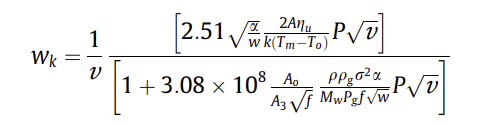

This equation is experimental and includes variables that relate to the movement of the cutting head such as the cutting speed, variables related to the material being cut such as density and temperature, and variables related to the laser itself such as the beam distribution factor. This equation also has some experimental factors that will vary based off of machine and laser type (A constants).

From experiments the following plots can be generating which describe the relationships between the cuttig speed, power and kerf width.

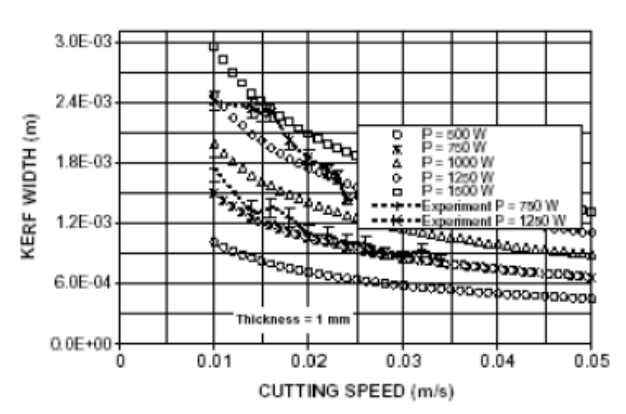 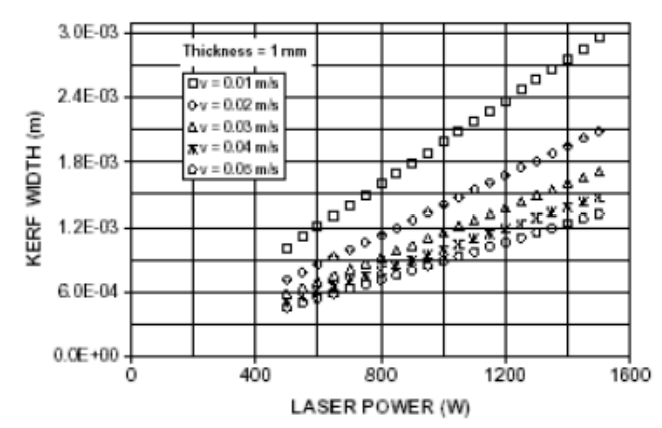

## 4.2. Heat Affected Zone (HAZ)
Due to laser cutting being a thermal process the thermal heat from the laser cutter will produce what is called a heat affected zone or HAZ. This is the area surrounding the cut where the metallurgical structure of the material is affected. Basically, the area affected by the heat but not melted by the laser. 

#### Why is the HAZ important?
This is important as the HAZ can change a materials crystal structure and hardness. due to the rapid thermal cycling. For example, in carbon steel the HAZ cab become harder and more brittle than the rest of the material which could lead to failure when under loading.

#### What decides the HAZ?
The width and severity of the HAZ can vary significantly depending on these factors:
1. Laser Power
2. Dwell Time
3. Assist Gas Temperature
4. Base Material Composition

In order to solve for the area affected by the HAZ you will have to calculate the temperature at different points surrounding the cut area to see if they fall within the threshold for transformation. This can be done through the below equation:
$$ T(x,y) = [\dfrac{\rho f}{2\pi kg}]e^{\dfrac{vx}{2D}}K_o [\dfrac{V}{2D}][\sqrt{(x^2 + y^2)}] + T_o$$

This equation often isn't solved by hand as it would be hard to check every point surrounding this area. For most cases when the HAZ could cause an issue with the manufactured piece heat transfer simulations are performed to check if the HAZ poses an issue.

However, from experiments certain correlations have been developed to show how the power and cutting speed of the laser affect the width of the HAZ.

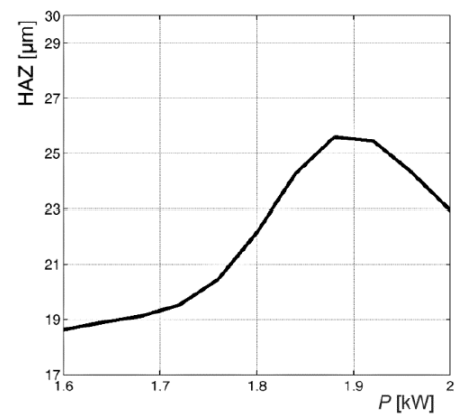 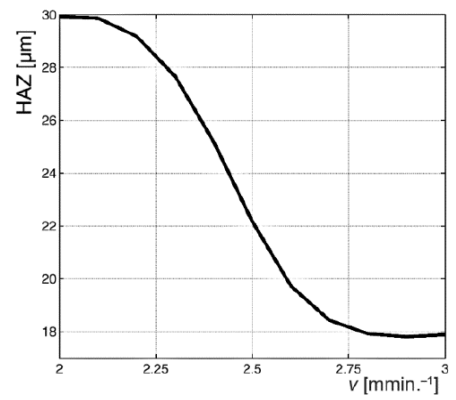

# 5. Referances

[1] Badoniya, Pushkal. “CO2 Laser Cutting of Different Materials-A Review.” International Journal of Engineering and Technical Research, vol. 5, 2018. 

[2] Belhadj, A, et al. “Simulation of the HAZ and magnetic properties of laser cut non-oriented electrical steels.” Journal of Magnetism and Magnetic      Materials, vol. 248, no. 1, July 2002, pp. 34–44, https://doi.org/10.1016/s0304-8853(02)00064-1.

[3] Gaussian Beam Propagation | Edmund Optics, www.edmundoptics.com/knowledge-center/application-notes/lasers/gaussian-beam-propagation/. Accessed 13 Apr. 2026. 

[4] “Heat-Affected Zone (HAZ): Laser Cutting.” Midwest Metal Fabrications, Midwest Metal Fabrications, www.mwmetalfab.com/glossary-terms/heat-affected-zone-haz. Accessed 13 Apr. 2026. 

[5] “Industrial Quick Search.” Uses and Types of Laser Cutting, IQS Directory, www.iqsdirectory.com/articles/laser-cutting-service/laser-cutting.html. Accessed 13 Apr. 2026. 

[6] Kaplan, A. “A model of deep penetration laser welding based on calculation of the Keyhole profile.” Journal of Physics D: Applied Physics, vol. 27, no. 9, 14 Sept. 1994, pp. 1805–1814, https://doi.org/10.1088/0022-3727/27/9/002. 

[7] “Laser Cutting: Advantages & Inconvenients.” Dassault Systèmes, 14 June 2023, www.3ds.com/make/solutions/blog/laser-cutting-advantages-inconvenients. 

[8] Lee, Cameron. “What Is Laser Cutting Kerf?” ACCURL, 26 Aug. 2024, www.accurl.com/blog/laser-cutting-kerf/. 

[9] Senthikumar, V. “Laser cutting process – A Review.” INTERNATIONAL JOURNAL OF DARSHAN INSTITUTE ON ENGINEERING RESEARCH & EMERGING TECHNOLOGIES, vol. 3, no. 1, 2014. 

[10] “Standard Laser Cutting Tolerances - a-Laser Precision Laser Cutting.” A, 29 Aug. 2025, a-laser.com/standard-laser-cutting-tolerances/. 

[11] Support.Thunderlaserusa.Com, support.thunderlaserusa.com/portal/en/kb/articles/laser-lenses-optics-and-focus#3_FOCUSING_LENSES. Accessed 12 Apr. 2026. 

[12] Yilbas, Bekir Sami, et al. “Laser cutting of various materials: Kerf width size analysis and life cycle assessment of cutting process.” Optics &amp; Laser Technology, vol. 93, Aug. 2017, pp. 67–73, https://doi.org/10.1016/j.optlastec.2017.02.014. 